In [1]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
spark = SparkSession.builder \
.appName("Read Parquet") \
    .config("spark.driver.memory", "12g")\
        .getOrCreate()

data = spark.read.parquet("training_data/combined_yellow_fhvhv.parquet")
print(data.count())
data.show(20)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/27 12:20:18 WARN Utils: Your hostname, aydin-khan-desktop, resolves to a loopback address: 127.0.1.1; using 192.168.1.18 instead (on interface wlp11s0)
26/08/27 12:20:18 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/08/27 12:20:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where app

330980
+----------+------------+------------------+------------------+-----------------------+-----------------------+------------------------+------------------+------------------+--------------------+--------------------+---------------------+
|      date|PULocationID|     total_revenue| log_total_revenue|lag_1_log_total_revenue|lag_7_log_total_revenue|lag_14_log_total_revenue|        driver_pay|    log_driver_pay|lag_1_log_driver_pay|lag_7_log_driver_pay|lag_14_log_driver_pay|
+----------+------------+------------------+------------------+-----------------------+-----------------------+------------------------+------------------+------------------+--------------------+--------------------+---------------------+
|2023-01-01|           7|1685.8999999999999| 7.430647803966266|                   NULL|                   NULL|                    NULL|135104.27000000005| 11.81380953132961|                NULL|                NULL|                 NULL|
|2023-01-01|          56|244.20999999

# Bringing in the other features
We will bring in the external data as additional predictors for our models to gauge demand and competition with taxis.

In [2]:
from utils import add_stations
station_data = spark.read.csv('data/station_data.csv', header=True, inferSchema=True)
station_data.show(1)

+------------+----------+----------+--------+-------+--------------------+-------+-----+--------------+---------+-------------+--------------+---------------------+---------------------+---+--------------+--------------+---------+--------------------+
|GTFS Stop ID|Station ID|Complex ID|Division|   Line|           Stop Name|Borough|  CBD|Daytime Routes|Structure|GTFS Latitude|GTFS Longitude|North Direction Label|South Direction Label|ADA|ADA Northbound|ADA Southbound|ADA Notes|        Georeference|
+------------+----------+----------+--------+-------+--------------------+-------+-----+--------------+---------+-------------+--------------+---------------------+---------------------+---+--------------+--------------+---------+--------------------+
|         R01|         1|         1|     BMT|Astoria|Astoria-Ditmars Blvd|      Q|false|           N W| Elevated|    40.775036|    -73.912034|            Last Stop|            Manhattan|  0|             0|             0|     NULL|POINT (-73.912

In [3]:
data_1 = add_stations(station_data, data, spark)

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_versi

In [4]:
data_1.show(20)
print(data_1.count())

+----------+------------+------------------+------------------+-----------------------+-----------------------+------------------------+------------------+------------------+--------------------+--------------------+---------------------+------------+
|      date|PULocationID|     total_revenue| log_total_revenue|lag_1_log_total_revenue|lag_7_log_total_revenue|lag_14_log_total_revenue|        driver_pay|    log_driver_pay|lag_1_log_driver_pay|lag_7_log_driver_pay|lag_14_log_driver_pay|num_stations|
+----------+------------+------------------+------------------+-----------------------+-----------------------+------------------------+------------------+------------------+--------------------+--------------------+---------------------+------------+
|2023-01-01|           7|1685.8999999999999| 7.430647803966266|                   NULL|                   NULL|                    NULL|135104.27000000005| 11.81380953132961|                NULL|                NULL|                 NULL|      

In [5]:
from utils import add_unemployment_rate
data_2 = add_unemployment_rate(data_1, spark)
print(data_2.count())
data_2.printSchema()


330980
root
 |-- date: date (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- log_total_revenue: double (nullable = true)
 |-- lag_1_log_total_revenue: double (nullable = true)
 |-- lag_7_log_total_revenue: double (nullable = true)
 |-- lag_14_log_total_revenue: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- log_driver_pay: double (nullable = true)
 |-- lag_1_log_driver_pay: double (nullable = true)
 |-- lag_7_log_driver_pay: double (nullable = true)
 |-- lag_14_log_driver_pay: double (nullable = true)
 |-- num_stations: long (nullable = false)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- unemployment_rate: double (nullable = true)



# Replacing NULLs in unemployment_rate with linear interpolation

In [6]:
from pyspark.sql.window import Window

# Get the monthly unemployment rate for each location
monthly = (
    data_2
    .groupBy("PULocationID", "Year", "Month")
    .agg(
        F.first("unemployment_rate", ignorenulls=True).alias("monthly_rate")
    )
)

# Window over unique monthly observations
window = (
    Window
    .partitionBy("PULocationID", "Year")
    .orderBy("Month")
)

# Get previous and next month's rates
monthly = (
    monthly
    .withColumn("prev_rate", F.lag("monthly_rate").over(window))
    .withColumn("next_rate", F.lead("monthly_rate").over(window))
)

# Calculate October's interpolated value
monthly = monthly.withColumn(
    "interpolated_rate",
    F.when(
        (F.col("Year") == 2025) &
        (F.col("Month") == 10) &
        F.col("monthly_rate").isNull() &
        F.col("prev_rate").isNotNull() &
        F.col("next_rate").isNotNull(),
        (F.col("prev_rate") + F.col("next_rate")) / 2
    ).otherwise(F.col("monthly_rate"))
)

# Join ONLY on the unique monthly key
data_2 = (
    data_2
    .drop("unemployment_rate")
    .join(
        monthly.select(
            "PULocationID",
            "Year",
            "Month",
            F.col("interpolated_rate").alias("unemployment_rate")
        ),
        on=["PULocationID", "Year", "Month"],
        how="left"
    )
)
print(data_2.count())

330980


In [7]:
data_2.filter(data_2['unemployment_rate'].isNull()).count()

0

In [8]:
zone_lookup = spark.read.csv('data/taxi_zone_lookup.csv', header=True, inferSchema=True)
# add a column to data_2 with the borough name for each PULocationID
data_2 = data_2.join(zone_lookup.select(F.col("LocationID").alias("PULocationID"), F.col("Borough").alias("PU_Borough")), on="PULocationID", how="left")
data_2.show()

+------------+----+-----+----------+------------------+------------------+-----------------------+-----------------------+------------------------+------------------+------------------+--------------------+--------------------+---------------------+------------+-----------------+----------+
|PULocationID|Year|Month|      date|     total_revenue| log_total_revenue|lag_1_log_total_revenue|lag_7_log_total_revenue|lag_14_log_total_revenue|        driver_pay|    log_driver_pay|lag_1_log_driver_pay|lag_7_log_driver_pay|lag_14_log_driver_pay|num_stations|unemployment_rate|PU_Borough|
+------------+----+-----+----------+------------------+------------------+-----------------------+-----------------------+------------------------+------------------+------------------+--------------------+--------------------+---------------------+------------+-----------------+----------+
|         177|2023|    1|2023-01-01|              69.8| 4.259859000699674|                   NULL|                   NULL|  

In [9]:
# rename all boroughs other than Manhattan and Queens to "Other"
data_2 = data_2.withColumn("PU_Borough", F.when(F.col("PU_Borough").isin(["Manhattan", "Queens"]), F.col("PU_Borough")).otherwise("Other"))
# one hot encode the PU_Borough column
data_2 = data_2.withColumn("PU_Borough_Manhattan", F.when(F.col("PU_Borough") == "Manhattan", 1).otherwise(0))
data_2 = data_2.withColumn("PU_Borough_Queens", F.when(F.col("PU_Borough") == "Queens", 1).otherwise(0))
data_2 = data_2.drop("PU_Borough")
data_2.show()

+------------+----+-----+----------+------------------+------------------+-----------------------+-----------------------+------------------------+------------------+------------------+--------------------+--------------------+---------------------+------------+-----------------+--------------------+-----------------+
|PULocationID|Year|Month|      date|     total_revenue| log_total_revenue|lag_1_log_total_revenue|lag_7_log_total_revenue|lag_14_log_total_revenue|        driver_pay|    log_driver_pay|lag_1_log_driver_pay|lag_7_log_driver_pay|lag_14_log_driver_pay|num_stations|unemployment_rate|PU_Borough_Manhattan|PU_Borough_Queens|
+------------+----+-----+----------+------------------+------------------+-----------------------+-----------------------+------------------------+------------------+------------------+--------------------+--------------------+---------------------+------------+-----------------+--------------------+-----------------+
|         177|2023|    1|2023-01-01|    

In [10]:
# add a "day of week" column to the data_2 dataframe
data_2 = data_2.withColumn("day_of_week", F.date_format(F.col("date"), "E"))
data_2 = data_2.withColumn("day_of_week", F.when(F.col("day_of_week") == "Mon", 1)
    .when(F.col("day_of_week") == "Tue", 2)
    .when(F.col("day_of_week") == "Wed", 3)
    .when(F.col("day_of_week") == "Thu", 4)
    .when(F.col("day_of_week") == "Fri", 5)
    .when(F.col("day_of_week") == "Sat", 6)
    .when(F.col("day_of_week") == "Sun", 7)
)
data_2.show(10)

+------------+----+-----+----------+------------------+------------------+-----------------------+-----------------------+------------------------+------------------+------------------+--------------------+--------------------+---------------------+------------+-----------------+--------------------+-----------------+-----------+
|PULocationID|Year|Month|      date|     total_revenue| log_total_revenue|lag_1_log_total_revenue|lag_7_log_total_revenue|lag_14_log_total_revenue|        driver_pay|    log_driver_pay|lag_1_log_driver_pay|lag_7_log_driver_pay|lag_14_log_driver_pay|num_stations|unemployment_rate|PU_Borough_Manhattan|PU_Borough_Queens|day_of_week|
+------------+----+-----+----------+------------------+------------------+-----------------------+-----------------------+------------------------+------------------+------------------+--------------------+--------------------+---------------------+------------+-----------------+--------------------+-----------------+-----------+
|   

In [11]:
# Make sure date is an actual date type
data_2 = data_2.withColumn(
    "date",
    F.to_date("date", "yyyy-MM-dd")
)

# Define a window for each PULocationID, ordered chronologically
window_spec = Window.partitionBy("PULocationID").orderBy("date")

# Create the 1-day lag feature
data_2 = data_2.withColumn(
    "unemployment_rate_lag_1",
    F.lag("unemployment_rate", 1).over(window_spec)
)

# Optional: sort the final dataframe for display
data_2 = data_2.orderBy("date", "PULocationID")
print(data_2.count())
data_2.show()

330980
+------------+----+-----+----------+------------------+------------------+-----------------------+-----------------------+------------------------+------------------+------------------+--------------------+--------------------+---------------------+------------+-----------------+--------------------+-----------------+-----------+-----------------------+
|PULocationID|Year|Month|      date|     total_revenue| log_total_revenue|lag_1_log_total_revenue|lag_7_log_total_revenue|lag_14_log_total_revenue|        driver_pay|    log_driver_pay|lag_1_log_driver_pay|lag_7_log_driver_pay|lag_14_log_driver_pay|num_stations|unemployment_rate|PU_Borough_Manhattan|PU_Borough_Queens|day_of_week|unemployment_rate_lag_1|
+------------+----+-----+----------+------------------+------------------+-----------------------+-----------------------+------------------------+------------------+------------------+--------------------+--------------------+---------------------+------------+-----------------+-

In [12]:
drop_cols = ['total_revenue', 'log_driver_pay', 'driver_pay', 'unemployment_rate']
data_2 = data_2.drop(*drop_cols)
print(data_2.columns)

['PULocationID', 'Year', 'Month', 'date', 'log_total_revenue', 'lag_1_log_total_revenue', 'lag_7_log_total_revenue', 'lag_14_log_total_revenue', 'lag_1_log_driver_pay', 'lag_7_log_driver_pay', 'lag_14_log_driver_pay', 'num_stations', 'PU_Borough_Manhattan', 'PU_Borough_Queens', 'day_of_week', 'unemployment_rate_lag_1']


TEST_ZONE: 132
Training rows: 281316
Test rows:     177
+------------+
|PULocationID|
+------------+
|         132|
+------------+



26/08/27 12:20:34 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/08/27 12:20:45 WARN DAGScheduler: Broadcasting large task binary with size 1354.4 KiB
26/08/27 12:20:51 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/27 12:20:59 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB
26/08/27 12:21:07 WARN DAGScheduler: Broadcasting large task binary with size 8.2 MiB
26/08/27 12:21:16 WARN DAGScheduler: Broadcasting large task binary with size 1152.1 KiB
26/08/27 12:21:17 WARN DAGScheduler: Broadcasting large task binary with size 15.3 MiB
26/08/27 12:21:27 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/08/27 12:21:29 WARN DAGScheduler: Broadcasting large task binary with size 27.7 MiB
26/08/27 12:21:41 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB



Random Forest Model Performance
Test Zone: 132
RMSE:      1.5550
MAE:       0.5761
R²:        0.8803


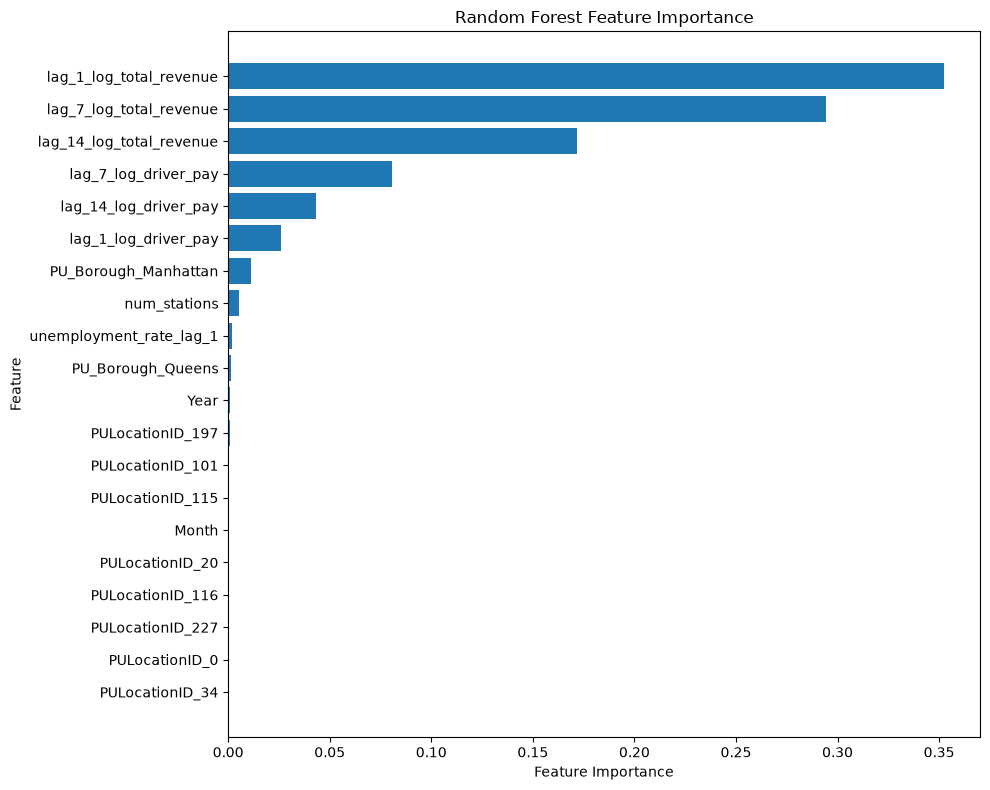

In [13]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# ============================================================
# 1. Set the test zone
# ============================================================

TEST_ZONE = 132   # <-- Change this to whichever PULocationID you want

# ============================================================
# 2. Create a separate DataFrame for modelling
# ============================================================

# Keep data_2 unchanged
model_data = data_2.drop(
    "date",
)

# Remove rows with missing values
model_data = model_data.dropna()

# ============================================================
# 3. Create chronological train/test sets
# ============================================================

# Training data:
# All locations, years 2023-2025
train_data = model_data.filter(
    (F.col("Year") >= 2023) &
    (F.col("Year") <= 2025)
)

# Test data:
# ONLY TEST_ZONE, Year = 2026
test_data = model_data.filter(
    (F.col("Year") == 2026) &
    (F.col("PULocationID") == TEST_ZONE)
)

print("========================================")
print(f"TEST_ZONE: {TEST_ZONE}")
print("========================================")
print(f"Training rows: {train_data.count()}")
print(f"Test rows:     {test_data.count()}")

# Check that test set contains exactly one zone
test_data.select("PULocationID").distinct().show()

# ============================================================
# 4. Prepare PULocationID for one-hot encoding
# ============================================================

# Convert PULocationID to string because it is categorical
train_data = train_data.withColumn(
    "PULocationID_str",
    F.col("PULocationID").cast("string")
)

test_data = test_data.withColumn(
    "PULocationID_str",
    F.col("PULocationID").cast("string")
)

# ============================================================
# 5. Index and one-hot encode PULocationID
# ============================================================

location_indexer = StringIndexer(
    inputCol="PULocationID_str",
    outputCol="PULocationID_index",
    handleInvalid="keep"
)

location_encoder = OneHotEncoder(
    inputCol="PULocationID_index",
    outputCol="PULocationID_encoded"
)

# Index and one-hot encode day_of_week
day_indexer = StringIndexer(
    inputCol="day_of_week",
    outputCol="dow_index",
    handleInvalid="keep"
)

day_encoder = OneHotEncoder(
    inputCol="dow_index",
    outputCol="dow_encoded"
)
# ============================================================
# 6. Define the remaining model features
# ============================================================

target = "log_total_revenue"

feature_cols = [
    "lag_1_log_total_revenue",
    "lag_7_log_total_revenue",
    "lag_14_log_total_revenue",
    "lag_1_log_driver_pay",
    "lag_7_log_driver_pay",
    "lag_14_log_driver_pay",
    "num_stations",
    "Year",
    "Month",
    "PU_Borough_Manhattan",
    "PU_Borough_Queens",
    "unemployment_rate_lag_1"
]

# ============================================================
# 7. Assemble all features
# ============================================================

assembler = VectorAssembler(
    inputCols=feature_cols + ["PULocationID_encoded", "dow_encoded"],
    outputCol="features"
)

# ============================================================
# 8. Create Random Forest
# ============================================================

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol=target,
    numTrees=100,
    maxDepth=10,
    seed=42
)

# ============================================================
# 9. Build the pipeline
# ============================================================

pipeline = Pipeline(
    stages=[
        location_indexer,
        location_encoder,
        day_indexer,
        day_encoder,
        assembler,
        rf
    ]
)

# ============================================================
# 10. Train the model
# ============================================================

model = pipeline.fit(train_data)

# ============================================================
# 11. Make predictions on the 2026 TEST_ZONE
# ============================================================

predictions = model.transform(test_data)


# ============================================================
# 12. Evaluate model performance
# ============================================================

rmse_evaluator = RegressionEvaluator(
    labelCol=target,
    predictionCol="prediction",
    metricName="rmse"
)

mae_evaluator = RegressionEvaluator(
    labelCol=target,
    predictionCol="prediction",
    metricName="mae"
)

r2_evaluator = RegressionEvaluator(
    labelCol=target,
    predictionCol="prediction",
    metricName="r2"
)

rmse = rmse_evaluator.evaluate(predictions)
mae = mae_evaluator.evaluate(predictions)
r2 = r2_evaluator.evaluate(predictions)

print("\n========================================")
print("Random Forest Model Performance")
print("========================================")
print(f"Test Zone: {TEST_ZONE}")
print(f"RMSE:      {rmse:.4f}")
print(f"MAE:       {mae:.4f}")
print(f"R²:        {r2:.4f}")
print("========================================")

# ============================================================
# 13. Extract feature importances
# ============================================================

# The Random Forest is the final stage of the pipeline
rf_model = model.stages[-1]

importances = rf_model.featureImportances

# The assembler determines the final feature ordering.
# Get the number of one-hot encoded location features.
location_size = (
    model.stages[1]
    .categorySizes[0]
)

# Build feature names corresponding to the VectorAssembler output
feature_names = feature_cols + [
    f"PULocationID_{i}"
    for i in range(location_size)
]

# Pair feature names with importance values
feature_importance = list(
    zip(
        feature_names,
        importances.toArray()
    )
)

# Sort by importance
feature_importance = sorted(
    feature_importance,
    key=lambda x: x[1],
    reverse=True
)


# ============================================================
# 14. Plot feature importance
# ============================================================

import matplotlib.pyplot as plt

# Plot only the top 20 features to keep the graph readable
top_n = 20

top_features = feature_importance[:top_n]

features = [x[0] for x in top_features]
importance_values = [x[1] for x in top_features]

plt.figure(figsize=(10, 8))

plt.barh(
    features[::-1],
    importance_values[::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Random Forest Feature Importance"
)

plt.tight_layout()
plt.show()

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


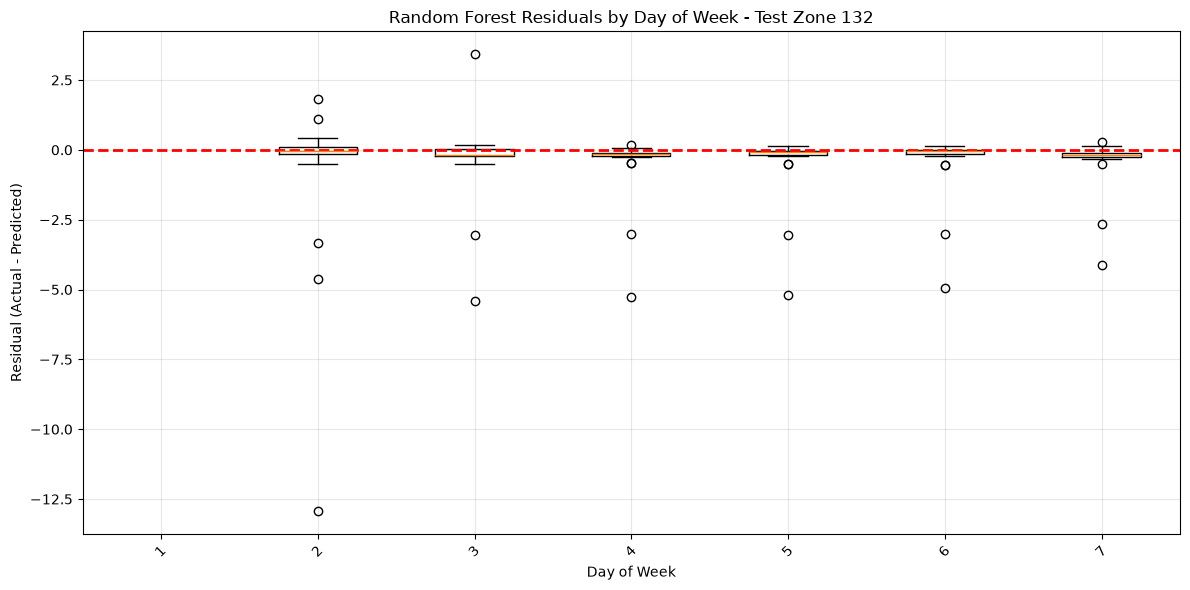

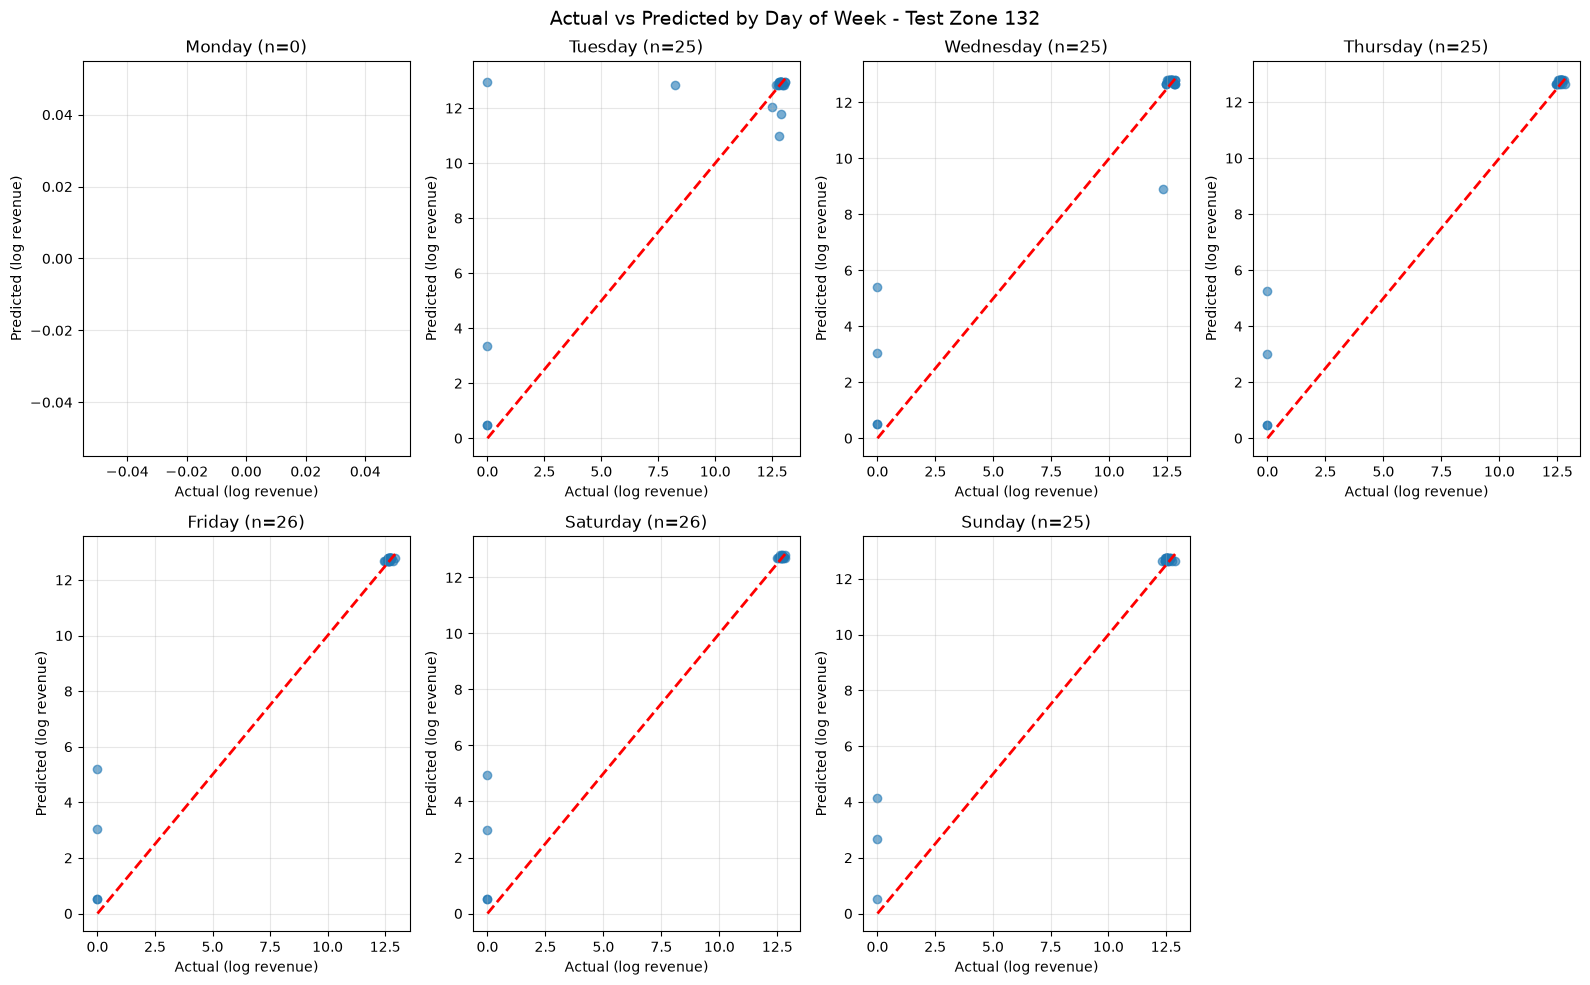


ANOVA Test: Do residuals differ by day?
F-statistic: 0.2426
P-value:     0.942927
Result: NO - No significant difference in residuals by day (p >= 0.05)


/tmp/ipykernel_10200/783862382.py:106: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = stats.f_oneway(*day_residuals)


In [14]:
import pandas as pd

# ============================================================
# 1. Add residuals to predictions
# ============================================================

predictions_with_residuals = predictions.withColumn(
    "residual",
    F.col(target) - F.col("prediction")
)

# ============================================================
# 2. Convert to Pandas for easier plotting
# ============================================================

predictions_pd = predictions_with_residuals.select(
    "day_of_week",
    "residual",
    target,
    "prediction"
).toPandas()

# ============================================================
# 3. Create day of week labels
# ============================================================

dow_labels = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

predictions_pd["day_name"] = predictions_pd["day_of_week"].map(dow_labels)

# ============================================================
# 4. Plot 1: Box plot of residuals by day of week
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
predictions_pd_sorted = predictions_pd.copy()
predictions_pd_sorted["day_name"] = pd.Categorical(
    predictions_pd_sorted["day_name"],
    categories=day_order,
    ordered=True
)
predictions_pd_sorted = predictions_pd_sorted.sort_values("day_name")

box_data = [predictions_pd_sorted[predictions_pd_sorted["day_name"] == day]["residual"].values 
            for day in day_order]

ax.boxplot(box_data, label=day_order)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero residual')
ax.set_xlabel("Day of Week")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title(f"Random Forest Residuals by Day of Week - Test Zone {TEST_ZONE}")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 7. Plot 3: Scatter plot of actual vs predicted by day
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, day in enumerate(day_order):
    day_data = predictions_pd[predictions_pd["day_name"] == day]
    
    ax = axes[idx]
    ax.scatter(day_data[target], day_data["prediction"], alpha=0.6)
    
    # Add perfect prediction line
    min_val = min(day_data[target].min(), day_data["prediction"].min())
    max_val = max(day_data[target].max(), day_data["prediction"].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    
    ax.set_xlabel("Actual (log revenue)")
    ax.set_ylabel("Predicted (log revenue)")
    ax.set_title(f"{day} (n={len(day_data)})")
    ax.grid(True, alpha=0.3)

# Hide the last unused subplot
axes[-1].set_visible(False)

plt.suptitle(f"Actual vs Predicted by Day of Week - Test Zone {TEST_ZONE}", fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 8. Statistical test: ANOVA on residuals by day
# ============================================================

from scipy import stats

day_residuals = [predictions_pd[predictions_pd["day_of_week"] == dow]["residual"].values 
                 for dow in range(7)]

f_stat, p_value = stats.f_oneway(*day_residuals)

# ============================================================
# 8. Statistical test: ANOVA on residuals by day
# ============================================================

from scipy import stats

# Only include days that have data
day_residuals = [predictions_pd[predictions_pd["day_of_week"] == dow]["residual"].values 
                 for dow in range(7) 
                 if len(predictions_pd[predictions_pd["day_of_week"] == dow]) > 0]

f_stat, p_value = stats.f_oneway(*day_residuals)

print("\n========================================")
print("ANOVA Test: Do residuals differ by day?")
print("========================================")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.6f}")
if p_value < 0.05:
    print("Result: YES - Residuals differ significantly by day (p < 0.05)")
else:
    print("Result: NO - No significant difference in residuals by day (p >= 0.05)")
print("========================================")

In [15]:
data_2.show(10)

+------------+----+-----+----------+-----------------+-----------------------+-----------------------+------------------------+--------------------+--------------------+---------------------+------------+--------------------+-----------------+-----------+-----------------------+
|PULocationID|Year|Month|      date|log_total_revenue|lag_1_log_total_revenue|lag_7_log_total_revenue|lag_14_log_total_revenue|lag_1_log_driver_pay|lag_7_log_driver_pay|lag_14_log_driver_pay|num_stations|PU_Borough_Manhattan|PU_Borough_Queens|day_of_week|unemployment_rate_lag_1|
+------------+----+-----+----------+-----------------+-----------------------+-----------------------+------------------------+--------------------+--------------------+---------------------+------------+--------------------+-----------------+-----------+-----------------------+
|           1|2023|    1|2023-01-01|6.049969276480545|                   NULL|                   NULL|                    NULL|                NULL|            

In [16]:
data_2.sort('date', ascending=False).show(10)

+------------+----+-----+----------+-----------------+-----------------------+-----------------------+------------------------+--------------------+--------------------+---------------------+------------+--------------------+-----------------+-----------+-----------------------+
|PULocationID|Year|Month|      date|log_total_revenue|lag_1_log_total_revenue|lag_7_log_total_revenue|lag_14_log_total_revenue|lag_1_log_driver_pay|lag_7_log_driver_pay|lag_14_log_driver_pay|num_stations|PU_Borough_Manhattan|PU_Borough_Queens|day_of_week|unemployment_rate_lag_1|
+------------+----+-----+----------+-----------------+-----------------------+-----------------------+------------------------+--------------------+--------------------+---------------------+------------+--------------------+-----------------+-----------+-----------------------+
|          56|2026|    6|2026-06-26|              0.0|                    0.0|                    0.0|                     0.0|                 0.0|            

In [26]:
print(data_2.columns)

['PULocationID', 'Year', 'Month', 'date', 'log_total_revenue', 'lag_1_log_total_revenue', 'lag_7_log_total_revenue', 'lag_14_log_total_revenue', 'lag_1_log_driver_pay', 'lag_7_log_driver_pay', 'lag_14_log_driver_pay', 'num_stations', 'PU_Borough_Manhattan', 'PU_Borough_Queens', 'day_of_week', 'unemployment_rate_lag_1']


In [ ]:
from pygam import LinearGAM, s, f
gam = LinearGAM(
    f(0) + s(1) + f(2) + f(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9) + s(10) + s(11) + s(12) + s(13)
)
X_train = train_data.select('PULocationID', 'Year', 'Month', 'day_of_week', 'lag_1_log_total_revenue', 'lag_7_log_total_revenue', 'lag_14_log_total_revenue', 'lag_1_log_driver_pay', 'lag_7_log_driver_pay', 'lag_14_log_driver_pay', 'num_stations', 'PU_Borough_Manhattan', 'PU_Borough_Queens', 'unemployment_rate_lag_1').toPandas()
y_train = train_data.select('log_total_revenue').toPandas()

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_versi

In [35]:
gam.fit(X_train, y_train)

LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, 
   terms=f(0) + s(1) + f(2) + f(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9) + s(10) + s(11) + s(12) + s(13) + intercept,
   tol=0.0001, verbose=False)

In [68]:
TEST_ZONE_GAM = 67
# Test data:
# ONLY TEST_ZONE, Year = 2026
test_data = model_data.filter(
    (F.col("Year") == 2026) &
    (F.col("PULocationID") == TEST_ZONE_GAM)
)
X_test = test_data.select('PULocationID', 'Year', 'Month', 'day_of_week', 'lag_1_log_total_revenue', 'lag_7_log_total_revenue', 'lag_14_log_total_revenue', 'lag_1_log_driver_pay', 'lag_7_log_driver_pay', 'lag_14_log_driver_pay', 'num_stations', 'PU_Borough_Manhattan', 'PU_Borough_Queens', 'unemployment_rate_lag_1').toPandas()
y_test = test_data.select('log_total_revenue').toPandas()
predictions = gam.predict(X_test)
# evaluate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print("\n========================================")
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R2 Score: {r2}")

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()



Mean Squared Error: 1.4649915128940294
Mean Absolute Error: 0.8717691076472062
R2 Score: 0.6558249472045199


In [40]:
gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                    384.7275
Link Function:                     IdentityLink Log Likelihood:                               -418025.5483
Number of Samples:                       281316 AIC:                                           836822.5517
                                                AICc:                                          836823.6136
                                                GCV:                                                1.1478
                                                Scale:                                              1.0701
                                                Pseudo R-Squared:                                   0.8975
Feature Function                  Lam

/tmp/ipykernel_10200/3358381670.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


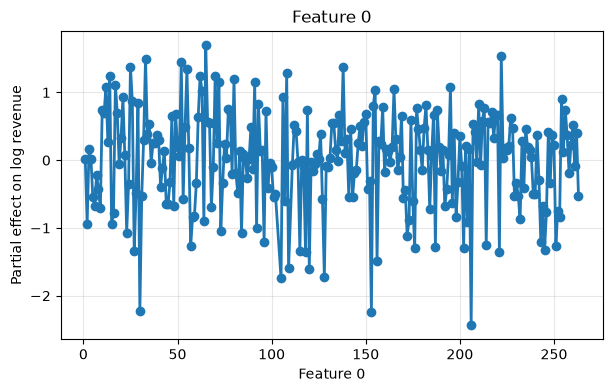

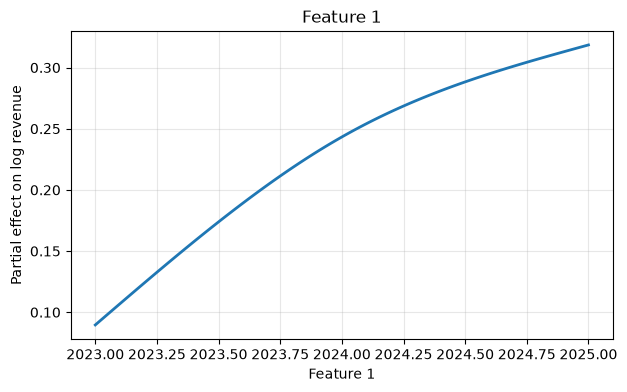

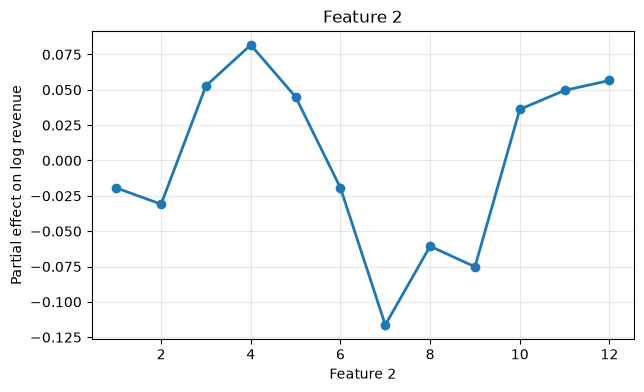

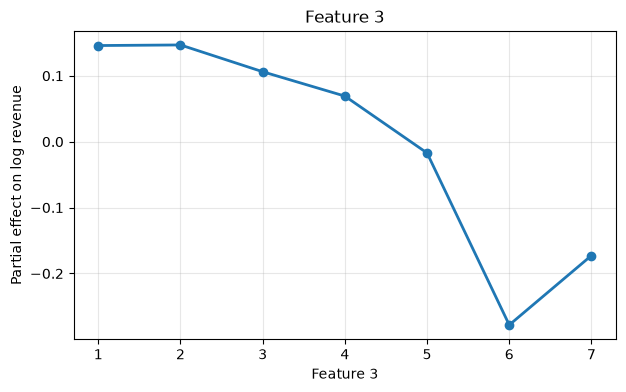

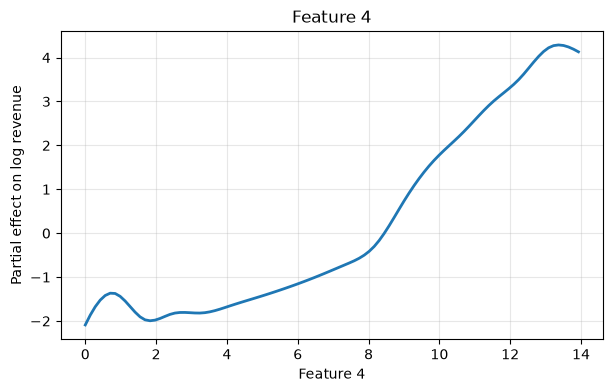

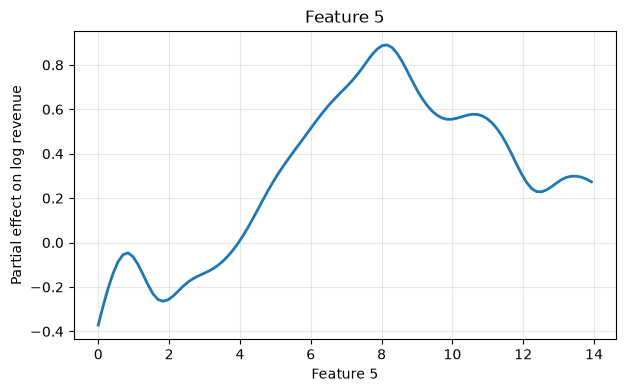

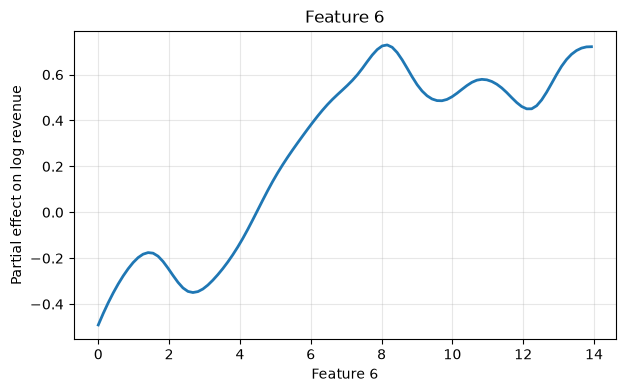

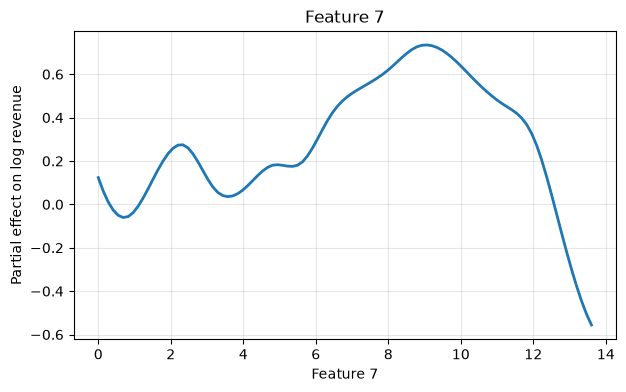

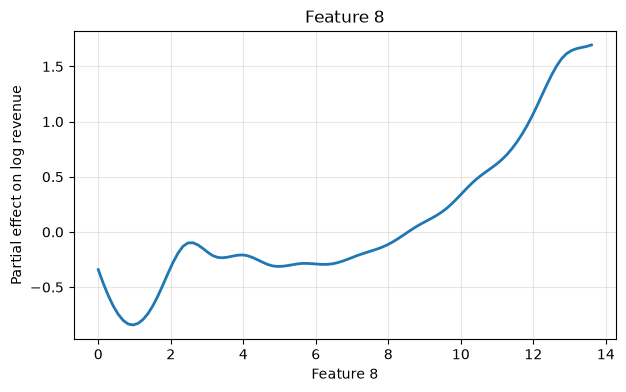

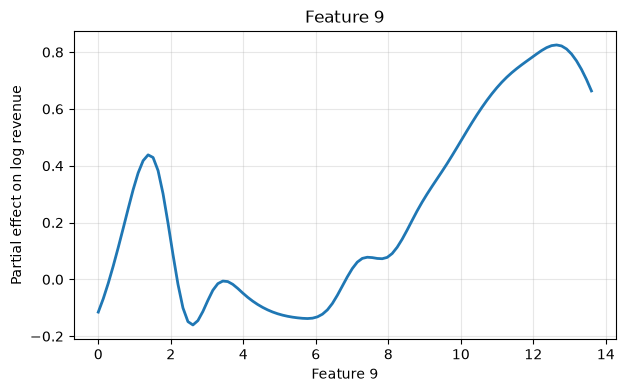

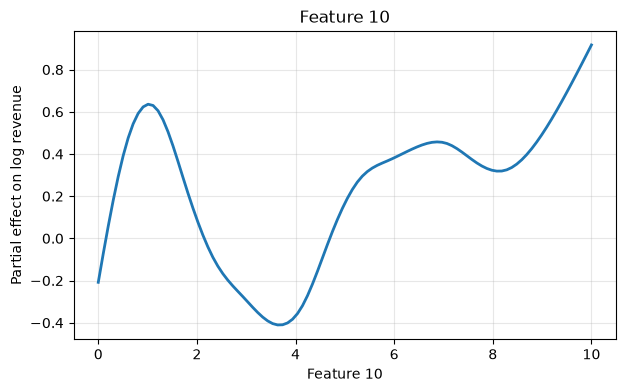

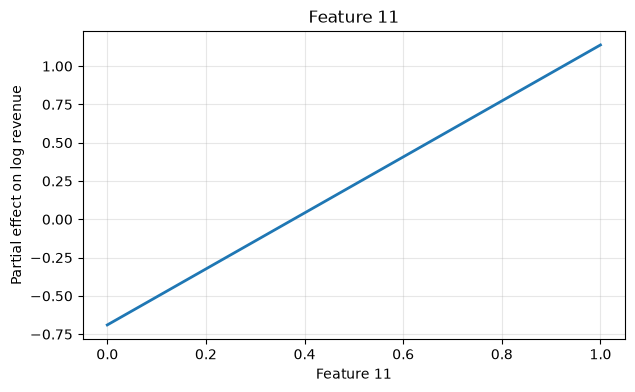

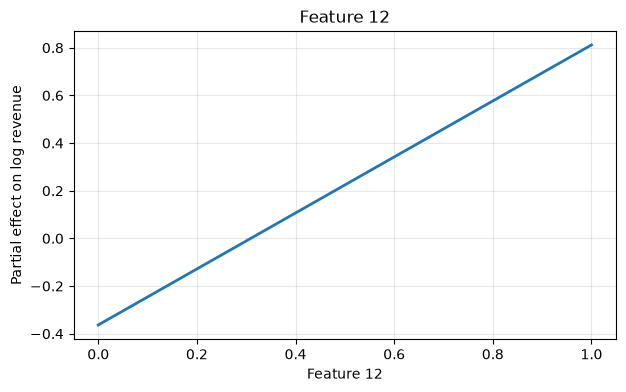

In [67]:
import numpy as np
categorical_indices = [0, 2, 3]

for i in range(len(gam.terms)):
    if i == 13:
        break
    
    # Create base grid
    XX = np.tile(X_train.mean(axis=0), (100, 1))
    
    if i in categorical_indices:
        # For categorical: use ONLY unique values
        unique_vals = np.sort(np.unique(X_train.values[:, i]))
        XX = np.tile(X_train.mean(axis=0), (len(unique_vals), 1))
        XX[:, i] = unique_vals
        x_axis = unique_vals
    else:
        # For continuous: use linspace
        XX[:, i] = np.linspace(X_train.values[:, i].min(), X_train.values[:, i].max(), 100)
        x_axis = XX[:, i]
    
    pdep = gam.partial_dependence(term=i, X=XX)
    
    plt.figure(figsize=(7, 4))
    plt.plot(x_axis, pdep, linewidth=2, marker='o' if i in categorical_indices else '')
    plt.xlabel(f"Feature {i}")
    plt.ylabel("Partial effect on log revenue")
    plt.title(f"Feature {i}")
    plt.grid(alpha=0.3)
    plt.show()

In [66]:
# Debug: check what XX contains for a few features
for i in range(3):
    XX = np.tile(X_train.mean(axis=0), (100, 1))
    XX[:, i] = np.linspace(X_train.values[:, i].min(), X_train.values[:, i].max(), 100)
    
    print(f"Feature {i}:")
    print(f"  Min: {XX[:, i].min()}, Max: {XX[:, i].max()}")
    print(f"  Sample values: {XX[:5, i]}")

Feature 0:
  Min: 1.0, Max: 263.0
  Sample values: [ 1.          3.64646465  6.29292929  8.93939394 11.58585859]
Feature 1:
  Min: 2023.0, Max: 2025.0
  Sample values: [2023.         2023.02020202 2023.04040404 2023.06060606 2023.08080808]
Feature 2:
  Min: 1.0, Max: 12.0
  Sample values: [1.         1.11111111 1.22222222 1.33333333 1.44444444]
